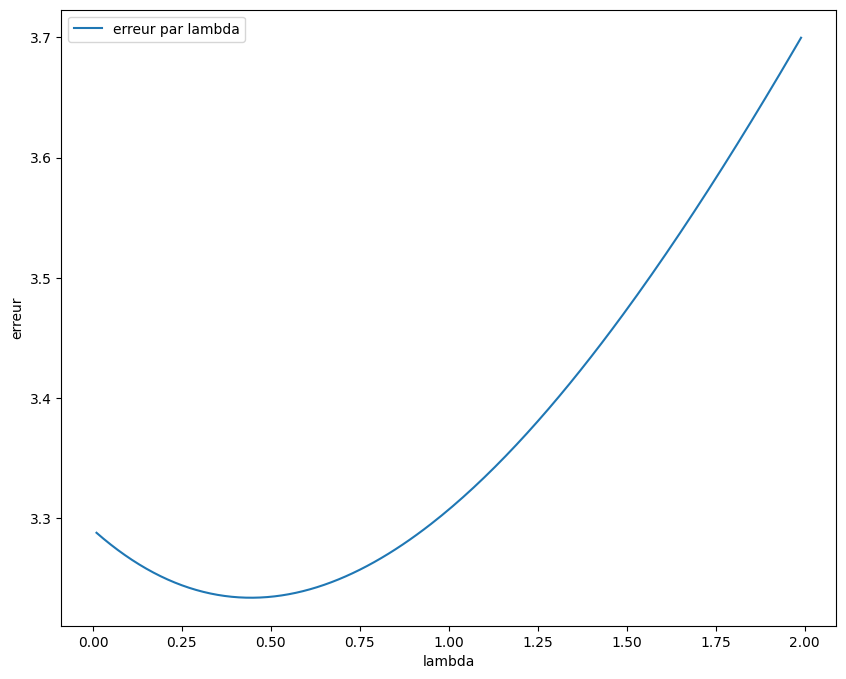

lambda optimal = 0.44


In [85]:
import matplotlib.pyplot as plt
import numpy as np

# Question 1
n_samples = 20
dim = 8
X = np.random.standard_normal((n_samples, dim))
beta_star = np.array([5, 3, 0, 0, 1.5, 0, 0, 0])
Y = np.array([np.dot(X[i], beta_star) + np.random.standard_normal() for i in range(n_samples)])

# Question 2
lam_grid = np.arange(0.01, 2, 0.01)

def ridge_fit(X, Y, lam):
    return np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ Y)

err_lam = np.array([
    np.linalg.norm(X @ (ridge_fit(X, Y, lam_grid[i]) - beta_star))
    for i in range(len(lam_grid))
])

plt.figure(figsize=(10, 8))

plt.plot(lam_grid, err_lam, label="erreur par lambda")
plt.xlabel("lambda")
plt.ylabel("erreur")
plt.legend()
plt.show()

lambda_opt = lam_grid[np.argmin(err_lam)]
print("lambda optimal =", lambda_opt)

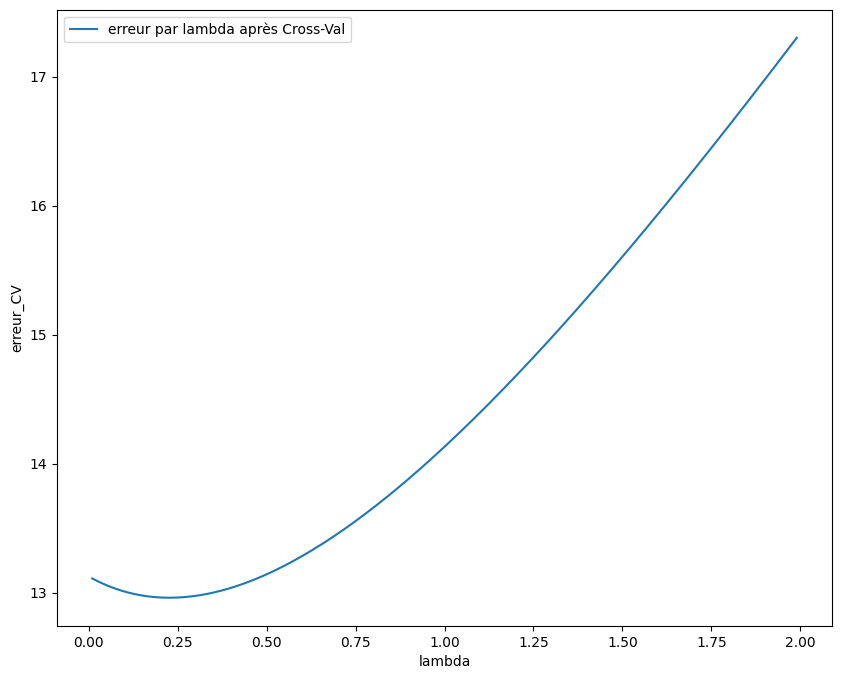

lambda CV = 0.23


In [86]:
# Question 3
from sklearn.model_selection import KFold


kf = KFold(n_splits=5, shuffle=True, random_state=0)
cv_errors = []

for lam in lam_grid:
    err = 0
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

        beta = ridge_fit(X_train, Y_train, lam)
        pred = X_val @ beta
        err += np.linalg.norm(pred - Y_val)**2

    cv_errors.append(err / kf.get_n_splits())

plt.figure(figsize=(10, 8))

plt.plot(lam_grid, cv_errors, label="erreur par lambda après Cross-Val")
plt.xlabel("lambda")
plt.ylabel("erreur_CV")
plt.legend()
plt.show()

lambda_cv = lam_grid[np.argmin(cv_errors)]
print("lambda CV =", lambda_cv)

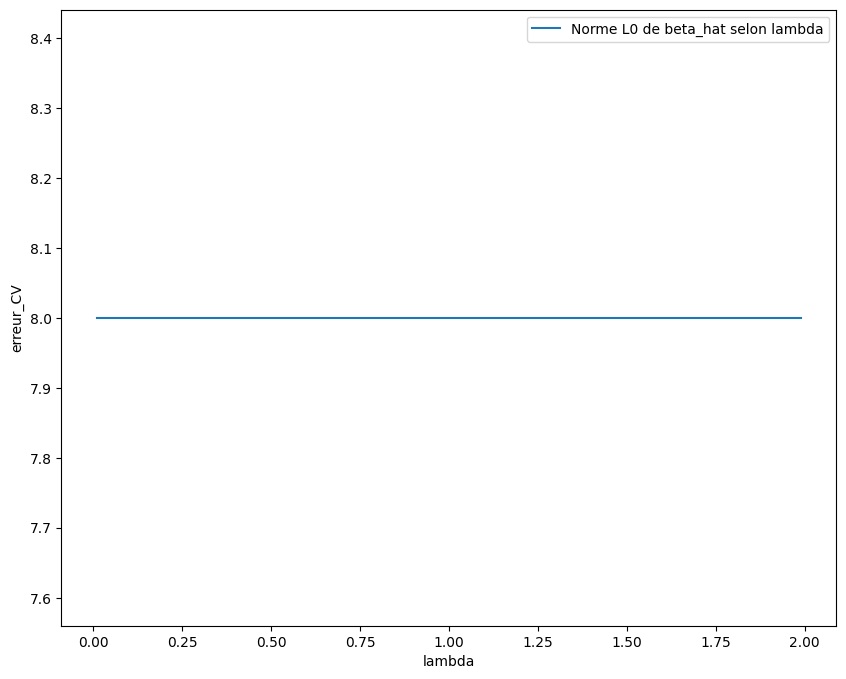

In [96]:
def l0_norm(beta, eps=1e-8):
    return np.sum(np.abs(beta) > eps)

beta_l0 = np.array([
    l0_norm(ridge_fit(X, Y, l))
    for l in lam_grid
])

plt.figure(figsize=(10, 8))

plt.plot(lam_grid, beta_l0, label="Norme L0 de beta_hat selon lambda")
plt.xlabel("lambda")
plt.ylabel("erreur_CV")
plt.legend()
plt.show()
